In [438]:
import pywt
import numpy as np
from scipy.io import wavfile
from scipy.signal import stft, cwt, ricker
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from scipy.signal.windows import hann
from scipy.fft import rfft, rfftfreq, irfft

In [439]:
# Uncomment these variables and assign appropriate expression or values
Fs = 4000
dt = 1/Fs  # Sampling period
L = 3 #Length of signal in seconds
t = np.arange(0, L, dt)

A = 0.9 #Signals amplitude
ω = 48 #Signals frequency

In [440]:
# Uncomment and assign the correct expression to the variable S1
S1 = A * np.sin(2 * np.pi * ω * t)
S2 = 0.8 * np.sin(2 * np.pi * 30 * t)
S3 = 0.7 * np.sin(2 * np.pi * 37 * t)
S4 = 0.4 * np.sin(2 * np.pi * 38 * t)
S5 = 0.3 * np.sin(2 * np.pi * 41 * t)

min_len = min(len(S1), len(S2), len(S3), len(S4), len(S5))

S1, S2, S3, S4, S5 = S1[:min_len], S2[:min_len], S3[:min_len], S4[:min_len], S5[:min_len]

S = S1 + S2 + S3 + S4 + S5
S_noise = np.load('gaussian_noise.npy')
min_len = min(len(S_noise), len(S))
S_noise = S_noise[:min_len]
S = S[:min_len]

In [441]:
X = S_noise + S

Text(0, 0.5, 'S(t)')

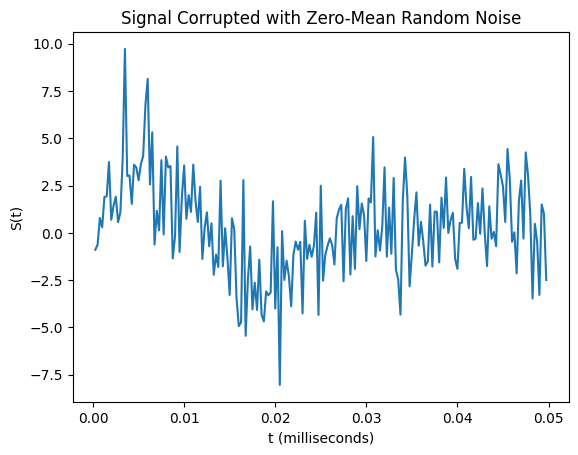

In [442]:
# Plot the signal in the time domain
plt.figure(1)
plt.plot(t[1:200], X[1:200])
plt.title('Signal Corrupted with Zero-Mean Random Noise')
plt.xlabel('t (milliseconds)')
plt.ylabel('S(t)')

In [443]:
# Compute the Fast Fourier Transform FFT (Y) of the noisy signal (X) and Calculate the Power spectrum (PSD)
Y = rfft(X) # Compute the fast Fourier transform (rfft()  returns only half the output that fft() does)
PSD = np.abs(Y) # Calculate the Power spectrum
freqs = rfftfreq(len(X), 1/Fs)

Text(0, 0.5, '|PSD|')

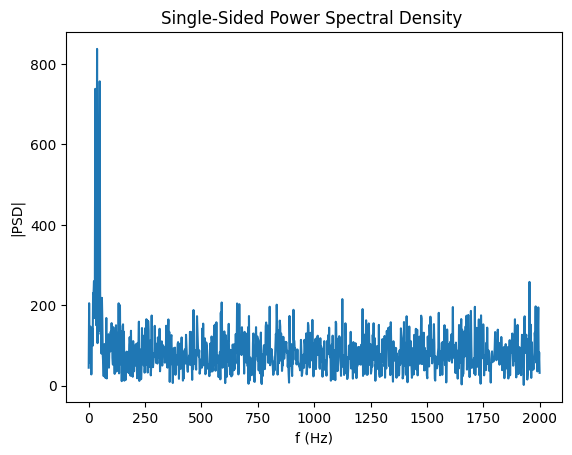

In [444]:
plt.figure()
plt.plot(freqs, PSD)
plt.title('Single-Sided Power Spectral Density ')
plt.xlabel('f (Hz)')
plt.ylabel('|PSD|')

In [445]:
# Uncomment the variables, threshold and assign appropriate value
threshold = 400

In [446]:
# Find all freqs with large PSD
# Zero out small Fourier coeffs. in Y
indices = PSD > threshold
Y_zeroed = indices * Y

In [447]:
# Uncomment the variable, ffilt and assign appropriate expression
# Inverse FFT for filtered time signal
ffilt = irfft(Y_zeroed)

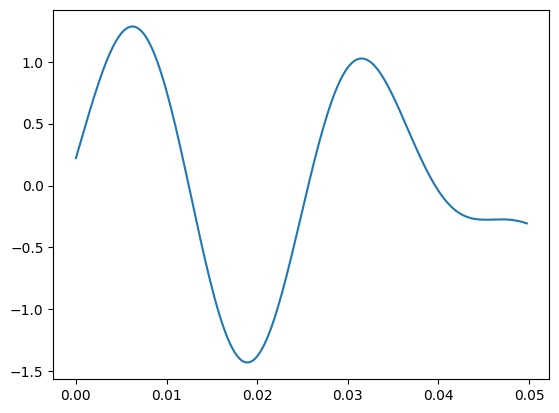

In [448]:
plt.plot(t[:200], ffilt[:200])
plt.show()

Text(0, 0.5, 'x(t)')

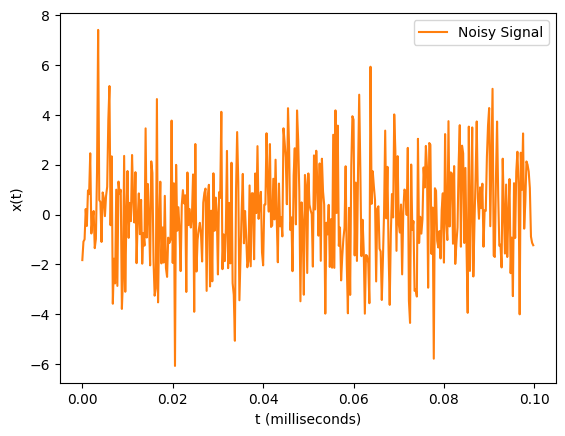

In [449]:
# Plot the noisy signal
plt.plot(t[:400], S_noise[:400], 'tab:orange', label='Noisy Signal')
plt.xlabel('t (milliseconds)')
plt.legend(fontsize=10, loc='upper right')
plt.ylabel('x(t)')

In [450]:
# Define the size of the average filter kernel (e.g., a window size of 3)
kernel_size = 15

In [451]:
# Create the average filter kernel
average_kernel = np.ones(kernel_size) / 15

In [452]:
# Convolve the signal with the average filter kernel
S_filtered = np.convolve(average_kernel, S_noise, mode = 'same')

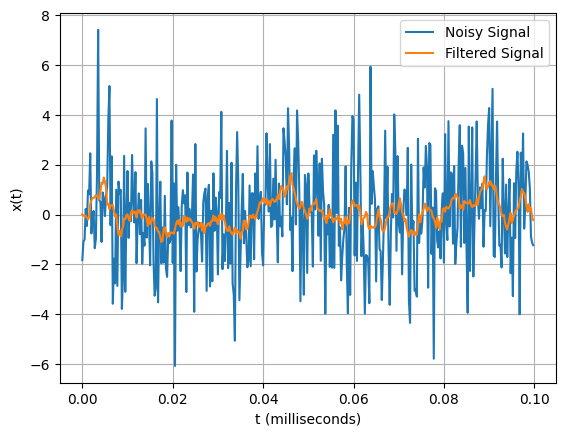

In [453]:
plt.plot(t[:400], S_noise[:400], label='Noisy Signal')
plt.plot(t[:400], S_filtered[:400], 'tab:orange', label='Filtered Signal')
plt.xlabel('t (milliseconds)')
plt.legend(fontsize=10, loc='upper right')
plt.ylabel('x(t)')
plt.grid()

In [454]:
# Define the parameters of the Gaussian filter
sigma = 1.0 # Standard deviation of the Gaussian distribution
filter_size = 9  # Size of the filter (odd number)

In [455]:
# Uncomment to create an array representing the 1D Gaussian kernel
z = np.linspace(-filter_size // 2, filter_size // 2, filter_size) # uncomment
gaussian_kernel = np.exp(-z ** 2 / (2 * sigma ** 2))
norm_gaussian_kernel = gaussian_kernel / np.sum(gaussian_kernel)  

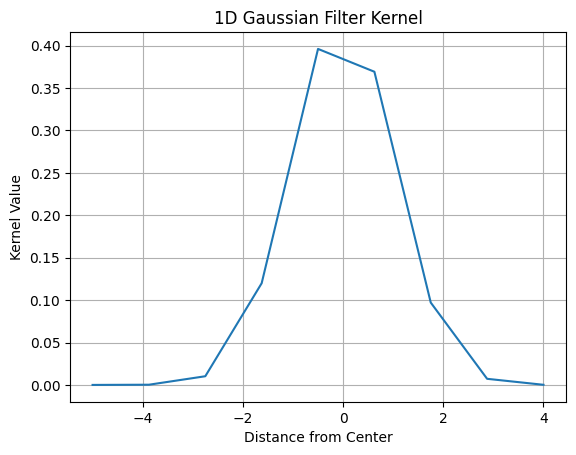

In [456]:
# Plot the Gaussian kernel
plt.plot(z, norm_gaussian_kernel)
plt.title('1D Gaussian Filter Kernel')
plt.xlabel('Distance from Center')
plt.ylabel('Kernel Value')
plt.grid(True)
plt.show()

In [457]:
# Convolve the signal with the average filter kernel
S_filtered = np.convolve(norm_gaussian_kernel, S_noise, mode = 'same')

Text(0, 0.5, 'y(t)')

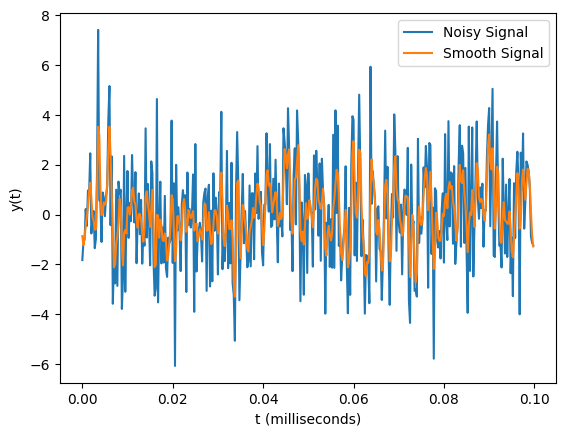

In [458]:
plt.plot(t[:400], S_noise[:400], label='Noisy Signal')
plt.plot(t[:400], S_filtered[:400], 'tab:orange', label='Smooth Signal')
plt.xlabel('t (milliseconds)')
plt.legend(fontsize=10, loc='upper right')
plt.ylabel('y(t)')

In [459]:
a = 0.95
N = 28
n = np.arange(0, N)
lags = np.arange(-(N-1), N)

In [460]:
# The Autocorrelation of the Exponential Sequence s
s = a ** n
c_auto_corr = np.correlate(s, s, mode = 'full')

In [461]:
# Analytically, c is estimated as
nn = np.arange(-(N-1), N, 1/Fs)
c_analytical = (1 - a**(2*(N-np.abs(nn)))) / (1 - a**2) * a**np.abs(nn)

Text(0.5, 0, 'Lag')

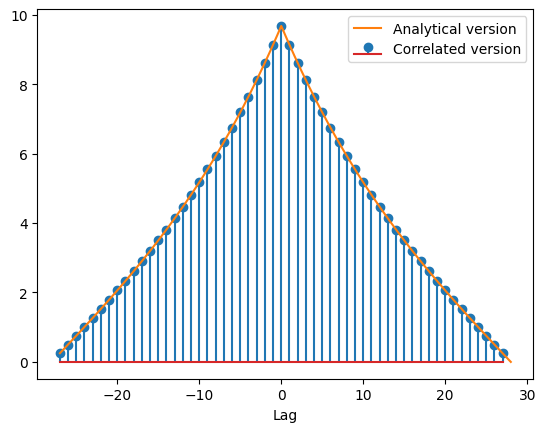

In [462]:
# Plot the analytical and correlate versions
plt.stem(lags, c_auto_corr, label='Correlated version')
plt.plot(nn, c_analytical, 'tab:orange', label='Analytical version')
plt.legend(fontsize=10, loc='upper right')
plt.xlabel('Lag')

In [463]:
filename = 'ECGDataset/train/Normal/(30).wav'
fs, x = wavfile.read('ECGDataset/train/Normal/(30).wav')
Dt = 1/fs
T = np.arange(0, 3, Dt)

In [464]:
M = 128  # window length
g = hann(M, sym = False)  # window
L = 0.75 * M # window Overlap
Ndft = 128  # FFT Length

In [465]:
# Using the Spectrogram with explicit parameters
fx, tx, sx = spectrogram(x, fs = fs, window = g, nperseg = M, noverlap = int(L), nfft = Ndft, scaling = 'spectrum')

In [466]:
# Using the STFT with explicit parameters
ft, tt, st = stft(x, fs=fs, window=g, noverlap=int(L), nperseg=M, nfft=Ndft, boundary=None, padded=False, scaling="spectrum")

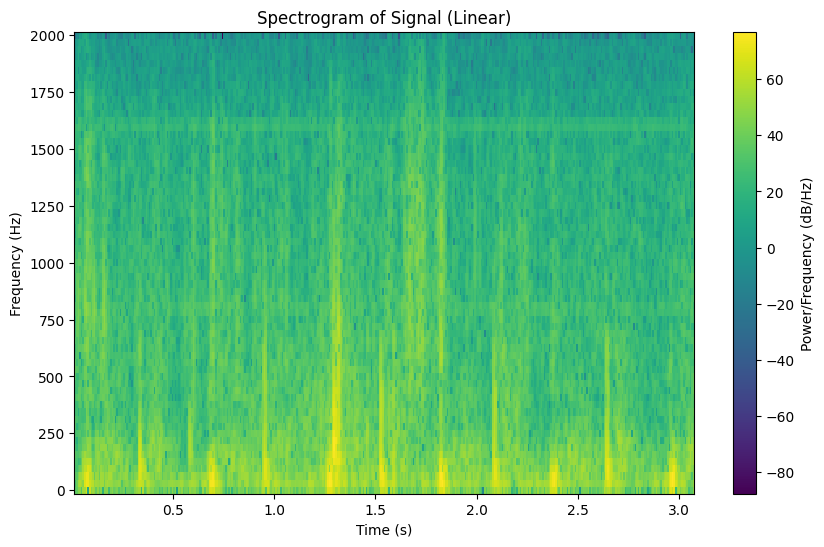

In [467]:
# Plot the spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(tx, fx, 10 * np.log10(np.abs(sx)), shading = 'auto')  # Convert to dB
plt.title('Spectrogram of Signal (Linear)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(label='Power/Frequency (dB/Hz)')
plt.show()

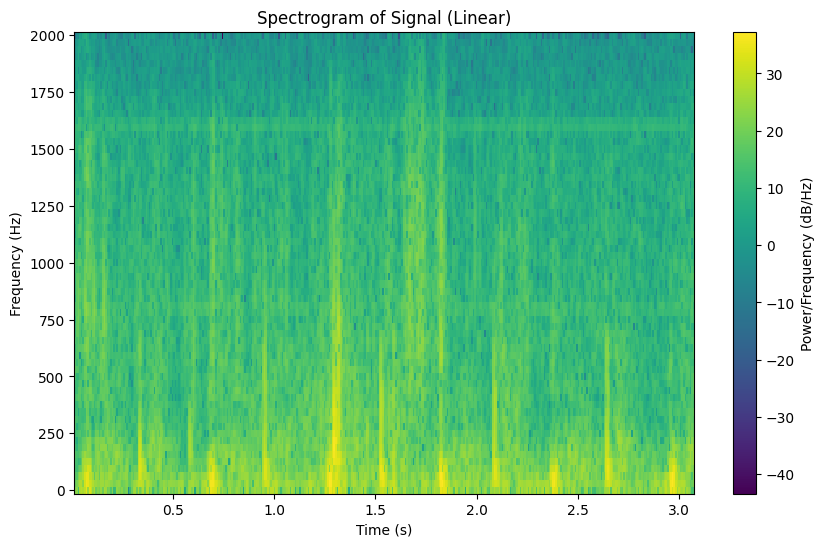

In [468]:
# Plot the spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(tt, ft, 10 * np.log10(np.abs(st)), shading = 'auto')  # Convert to dB
plt.title('Spectrogram of Signal (Linear)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(label='Power/Frequency (dB/Hz)')
plt.show()

In [469]:
#Compute Continuous Wavelet Transform
wavelet = mor1
scales = np.arange(1, 128)
cwt_results = pywt.cwt(x, scales, wavelet)

NameError: name 'mor1' is not defined